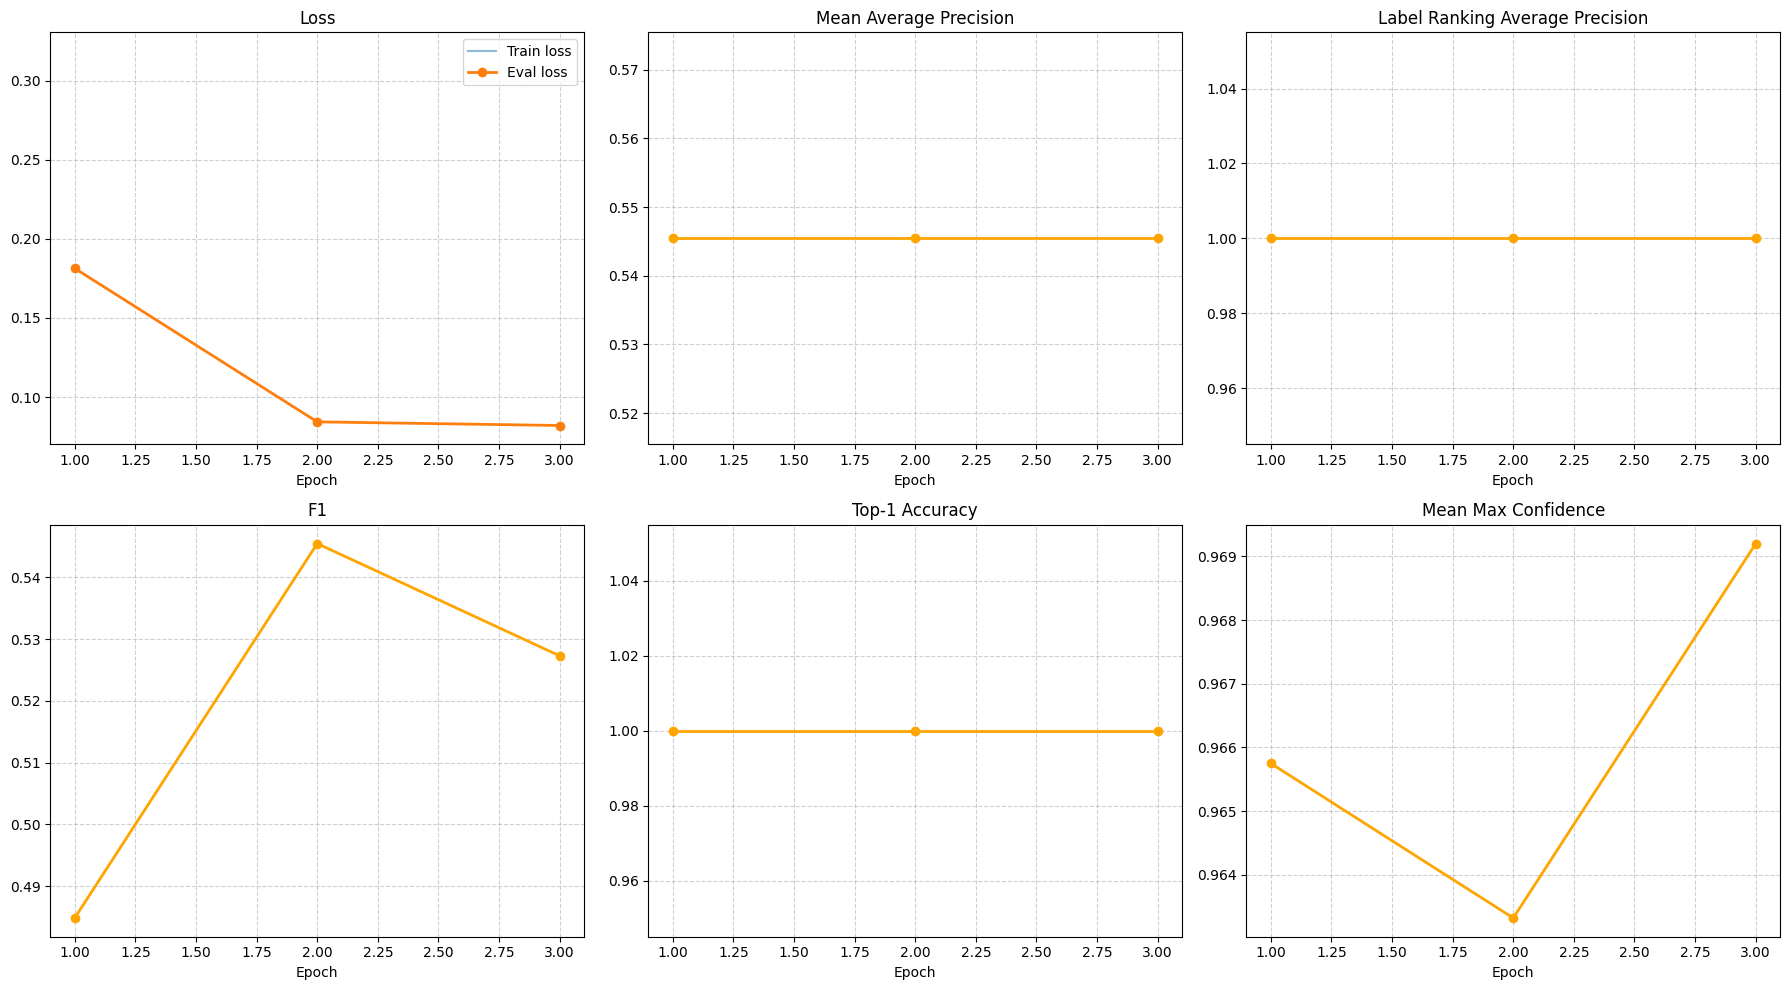

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt

with open('data/checkpoints/checkpoint-15/trainer_state.json', 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data['log_history'])

train_df = df[df['loss'].notna()]
eval_df = df[df['eval_loss'].notna()]

metrics = [
    ('eval_loss', 'Loss'),
    ('eval_mean_average_precision', 'Mean Average Precision'),
    ('eval_label_ranking_average_precision', 'Label Ranking Average Precision'),
    ('eval_f1', 'F1'),
    ('eval_top1_accuracy', 'Top-1 Accuracy'),
    ('eval_mean_max_confidence', 'Mean Max Confidence'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (col, title) in enumerate(metrics):
    ax = axes[i]

    if col == 'eval_loss':
        ax.plot(train_df['epoch'], train_df['loss'],
                label='Train loss', alpha=0.5)
        ax.plot(eval_df['epoch'], eval_df[col],
                label='Eval loss', marker='o', linewidth=2)
        ax.legend()
    else:
        ax.plot(eval_df['epoch'], eval_df[col],
                marker='o', color='orange', linewidth=2)

    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()